In [ ]:
# Colab-ready merged script for FL + Federated Unlearning + Enhancements
# Run in Google Colab. Make sure your dataset path is correct: "/content/drive/My Drive/FL_PROJECT"

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, ConcatDataset
import copy
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from google.colab import drive

In [ ]:
# -----------------------------
#  Setup & Preprocessing
# -----------------------------
drive.mount("/content/drive")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

data_root = "/content/drive/My Drive/FL_PROJECT"  # <-- make sure this path exists and contains class subfolders
assert os.path.exists(data_root), f"Dataset path not found: {data_root}"

dataset = datasets.ImageFolder(data_root, transform=transform)

# reproducibility
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu


In [ ]:
# split into train/test
train_ratio = 0.8
train_size = int(train_ratio * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# -----------------------------
#  Model definition
# -----------------------------
class CNNModel(nn.Module):
    def __init__(self, num_classes=2):
        super(CNNModel, self).__init__()

        self.conv_layer = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = self.fc_layer(x)
        return x


In [ ]:
# -----------------------------
#  Federated helpers
# -----------------------------
def split_data(dataset, num_clients):
    data_len = len(dataset)
    base_len = data_len // num_clients
    remainder = data_len % num_clients
    lengths = [base_len + 1 if i < remainder else base_len for i in range(num_clients)]
    return random_split(dataset, lengths)

def local_train(model, dataset, epochs=2, lr=0.001):
    model = copy.deepcopy(model)
    model.train()
    loader = DataLoader(dataset, batch_size=32, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
    return model.state_dict()

In [ ]:
def fed_avg(weight_list):
    avg_weights = copy.deepcopy(weight_list[0])
    for key in avg_weights.keys():
        for i in range(1, len(weight_list)):
            avg_weights[key] += weight_list[i][key]
        avg_weights[key] = torch.div(avg_weights[key], len(weight_list))
    return avg_weights


In [ ]:
def evaluate(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=32)
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total if total > 0 else 0.0


In [ ]:
# -----------------------------
#  Training - Federated rounds
# -----------------------------
num_clients = 3
rounds = 3

# Split datasets
client_datasets = split_data(train_dataset, num_clients)
client_test_datasets = split_data(test_dataset, num_clients)

# History trackers
client_model_history = []      # list of per-round per-client weights
global_model_history = []      # list of global weights snapshot before aggregation

# Initialize global model
global_model = CNNModel(len(dataset.classes)).to(device)   # <-- FIX: positional argument
global_weights = global_model.state_dict()

acc_per_round = []
client_acc_per_round = [[] for _ in range(num_clients)]

print("\nStarting Federated Training...")

for r in range(rounds):
    print(f"\n--- Round {r+1} ---")

    local_weights = []
    client_round_weights = []

    for i in range(num_clients):
        print(f"Training client {i+1}...")

        # FIX: pass num_classes as positional
        client_model = CNNModel(len(dataset.classes)).to(device)

        client_model.load_state_dict(global_weights)

        # Local training
        updated_weights = local_train(
            client_model,
            client_datasets[i],
            epochs=2,
            lr=0.001
        )

        local_weights.append(updated_weights)
        client_round_weights.append(copy.deepcopy(updated_weights))

        # Evaluate client on its own test set
        client_model.load_state_dict(updated_weights)
        client_acc = evaluate(client_model, client_test_datasets[i])
        client_acc_per_round[i].append(client_acc)

        print(f"Client {i+1} Accuracy on its test data: {client_acc:.4f}")

    # save per-client per-round weights
    client_model_history.append(client_round_weights)

    # save global weights snapshot BEFORE aggregation (for unlearning)
    global_model_history.append(copy.deepcopy(global_weights))

    # FedAvg aggregation
    global_weights = fed_avg(local_weights)
    global_model.load_state_dict(global_weights)

    # Global accuracy on global test set
    acc = evaluate(global_model, test_dataset)
    acc_per_round.append(acc)
    print(f"Global accuracy: {acc:.4f}")

print("\nFederated training completed.")



Starting Federated Training...

--- Round 1 ---
Training client 1...
Client 1 Accuracy on its test data: 0.5689
Training client 2...
Client 2 Accuracy on its test data: 0.6627
Training client 3...
Client 3 Accuracy on its test data: 0.7831
Global accuracy: 0.5090

--- Round 2 ---
Training client 1...
Client 1 Accuracy on its test data: 0.8144
Training client 2...
Client 2 Accuracy on its test data: 0.7590
Training client 3...
Client 3 Accuracy on its test data: 0.8012
Global accuracy: 0.8597

--- Round 3 ---
Training client 1...
Client 1 Accuracy on its test data: 0.8383
Training client 2...
Client 2 Accuracy on its test data: 0.8976
Training client 3...
Client 3 Accuracy on its test data: 0.8916
Global accuracy: 0.8517

Federated training completed.


In [ ]:
# Save accuracies before any unlearning (baseline)
client_acc_before_unlearning = [accs[-1] if len(accs)>0 else 0.0 for accs in client_acc_per_round]
global_acc_before_unlearning = acc_per_round[-1] if len(acc_per_round)>0 else evaluate(global_model, test_dataset)

# -----------------------------
#  Save teacher model (pre-unlearning)
# -----------------------------
teacher_model = CNNModel(num_classes=len(dataset.classes)).to(device)
teacher_model.load_state_dict(global_model.state_dict())
teacher_model.eval()

CNNModel(
  (conv_layer): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=65536, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=2, bias=True)
  )
)

In [ ]:
# -----------------------------
# FedEraser (gradient-ascent unlearning)
# -----------------------------
class FedEraser:
    def __init__(self, global_model, client_model_history, learning_rate, global_model_history):
        self.global_model = global_model
        self.client_model_history = client_model_history
        self.learning_rate = learning_rate
        self.global_model_history = global_model_history

    def apply_gradient_ascent(self, client_id):
        global_dict = self.global_model.state_dict()

        # Iterate backwards over rounds
        for round_idx in reversed(range(len(self.client_model_history))):
            client_weights = self.client_model_history[round_idx][client_id]
            prev_global_model = self.global_model_history[round_idx]

            # Compute delta = client - previous global
            update = {
                key: (client_weights[key].to(device) - prev_global_model[key].to(device))
                for key in global_dict.keys()
            }

            # Apply gradient-ascent step
            for key in global_dict.keys():
                global_dict[key] = global_dict[key].to(device) - self.learning_rate * update[key]

        self.global_model.load_state_dict(global_dict)
        print(f"Client {client_id+1} unlearned via FedEraser.")


In [ ]:
print("\nStarting Federated Unlearning (FedEraser)...")

fed_eraser = FedEraser(
    global_model=global_model,
    client_model_history=client_model_history,
    learning_rate=0.01,
    global_model_history=global_model_history
)

fed_eraser.apply_gradient_ascent(unlearn_client_id)



Starting Federated Unlearning (FedEraser)...
Client 2 unlearned via FedEraser.


In [ ]:
# Evaluate right after FedEraser
global_acc_after_federaser = evaluate(global_model, test_dataset)
print(f"Global accuracy after FedEraser only: {global_acc_after_federaser:.4f}")

Global accuracy after FedEraser only: 0.8497


In [ ]:
# -----------------------------
#  Enhancement 1: Knowledge Distillation (KD) - fine-tune student (global_model) with teacher (pre-unlearning)
# -----------------------------
print("\nStarting Knowledge Distillation fine-tuning...")


def knowledge_distillation_loss(student_output, teacher_output, labels, T=3, alpha=0.7):
    kd_loss = nn.KLDivLoss(reduction='batchmean')(
        nn.LogSoftmax(dim=1)(student_output / T),
        nn.Softmax(dim=1)(teacher_output / T)
    ) * (T * T)
    ce_loss = nn.CrossEntropyLoss()(student_output, labels)
    return alpha * kd_loss + (1 - alpha) * ce_loss

def kd_fine_tune(student_model, teacher_model, datasets, epochs=2, lr=5e-4):
    optimizer = optim.Adam(student_model.parameters(), lr=lr)
    student_model.train()
    teacher_model.eval()
    for epoch in range(epochs):
        for client_data in datasets:
            loader = DataLoader(client_data, batch_size=32, shuffle=True)
            for images, labels in loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                student_output = student_model(images)
                with torch.no_grad():
                    teacher_output = teacher_model(images)
                loss = knowledge_distillation_loss(student_output, teacher_output, labels, T=3, alpha=0.7)
                loss.backward()
                optimizer.step()

remaining_datasets = [client_datasets[i] for i in range(num_clients) if i != unlearn_client_id]
if len(remaining_datasets) == 0:
    print("Warning: no remaining clients to fine-tune on!")
else:
    kd_fine_tune(global_model, teacher_model, remaining_datasets, epochs=2, lr=5e-4)

global_acc_after_kd = evaluate(global_model, test_dataset)
print(f"Global accuracy after KD: {global_acc_after_kd:.4f}")





Starting Knowledge Distillation fine-tuning...
Global accuracy after KD: 0.8758


In [ ]:
# -----------------------------
#  Enhancement 2: Lightweight Model Scrubbing using diagonal-FIM approximation
# -----------------------------
print("\nComputing lightweight FIM from remaining data and applying scrubbing...")

def compute_fim(model, dataset):
    model.eval()
    fim = {name: torch.zeros_like(param).to(device) for name, param in model.named_parameters()}
    loader = DataLoader(dataset, batch_size=32)
    n = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        model.zero_grad()
        output = model(images)
        loss = nn.CrossEntropyLoss()(output, labels)
        loss.backward()
        for (name, param) in model.named_parameters():
            if param.grad is not None:
                fim[name] += (param.grad.detach() ** 2)
        n += images.size(0)
    if n == 0:
        return fim
    for name in fim.keys():
        fim[name] /= n
    return fim

# compute FIM on concatenated remaining data
if len(remaining_datasets) > 0:
    combined_remaining = ConcatDataset(remaining_datasets)
    fim = compute_fim(global_model, combined_remaining)
    # scrub step: small update proportional to fim (hyperparam scrub_lr)
    scrub_lr = 1e-3
    with torch.no_grad():
        for name, param in global_model.named_parameters():
            if name in fim:
                param.data.add_(-scrub_lr * fim[name])  # subtract small fim-weighted vector
    print("Model scrubbing applied.")
else:
    print("Skipping scrubbing: no remaining data available.")

global_acc_after_scrub = evaluate(global_model, test_dataset)
print(f"Global accuracy after scrubbing: {global_acc_after_scrub:.4f}")



Computing lightweight FIM from remaining data and applying scrubbing...
Model scrubbing applied.
Global accuracy after scrubbing: 0.8758


In [ ]:
# -----------------------------
#  Enhancement 3: Synthetic-label unlearning for the forgotten client (FedAF-style)
# -----------------------------
print("\nApplying Synthetic-Label Unlearning on forgotten client's local data...")

def synthetic_label_unlearning(model, dataset, epochs=1, lr=1e-3):
    loader = DataLoader(dataset, batch_size=32, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    model.train()
    num_classes = len(dataset.dataset.classes)   # <-- FIXED

    for epoch in range(epochs):
        for images, labels in loader:
            images = images.to(device)

            # random wrong labels
            fake_labels = torch.randint(0, num_classes, (labels.shape[0],)).to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, fake_labels)
            loss.backward()
            optimizer.step()




Applying Synthetic-Label Unlearning on forgotten client's local data...


In [ ]:
# After synthetic-label unlearning, compute the global accuracy
global_acc_after_synthetic = evaluate(global_model, test_dataset)
print(f"Global accuracy after synthetic-label unlearning: {global_acc_after_synthetic:.4f}")


Global accuracy after synthetic-label unlearning: 0.8758


In [ ]:
# -----------------------------
#  Final polishing: additional KD fine-tune on remaining clients
# -----------------------------
print("\nFinal KD fine-tuning on remaining clients (polish step)...")
if len(remaining_datasets) > 0:
    kd_fine_tune(global_model, teacher_model, remaining_datasets, epochs=1, lr=3e-4)
global_acc_after_all = evaluate(global_model, test_dataset)
print(f"Global accuracy after all enhancements: {global_acc_after_all:.4f}")



Final KD fine-tuning on remaining clients (polish step)...
Global accuracy after all enhancements: 0.8597


In [ ]:
# -----------------------------
#  Enhancement 4: Simple Membership Inference Attack (confidence-based) for verification
# -----------------------------
print("\nRunning simple Membership Inference Attack (MIA) - confidence based.")

def mia_confidence_score(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=32)
    confidences = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            top_conf, _ = torch.max(probs, dim=1)
            confidences.extend(top_conf.cpu().numpy())
    return float(np.mean(confidences)) if len(confidences)>0 else 0.0




Running simple Membership Inference Attack (MIA) - confidence based.


In [ ]:
# confidence on forgotten client's data before unlearning? We only have current model now.
# If you want pre-unlearning numbers you should have recorded them earlier (teacher_model can be used)
forgotten_conf_after = mia_confidence_score(global_model, client_datasets[unlearn_client_id])
forgotten_conf_teacher = mia_confidence_score(teacher_model, client_datasets[unlearn_client_id])
remaining_conf_after = mia_confidence_score(global_model, combined_remaining if len(remaining_datasets)>0 else test_dataset)

print(f"Avg confidence on FORGOTTEN client's data (teacher model, pre-unlearn): {forgotten_conf_teacher:.4f}")
print(f"Avg confidence on FORGOTTEN client's data (after unlearning): {forgotten_conf_after:.4f}")
print(f"Avg confidence on REMAINING data (after unlearning): {remaining_conf_after:.4f}")

Avg confidence on FORGOTTEN client's data (teacher model, pre-unlearn): 0.8567
Avg confidence on FORGOTTEN client's data (after unlearning): 0.8620
Avg confidence on REMAINING data (after unlearning): 0.8681


In [ ]:
# -----------------------------
#  Evaluate client accuracies after unlearning
# -----------------------------
client_acc_after_unlearning = []
print("\nEvaluating each client's model (global model used for inference) after unlearning:")
for i in range(num_clients):
    client_model = CNNModel(num_classes=len(dataset.classes)).to(device)
    client_model.load_state_dict(global_model.state_dict())
    acc = evaluate(client_model, client_test_datasets[i])
    client_acc_after_unlearning.append(acc)
    print(f"Client {i+1} Accuracy after unlearning: {acc:.4f}")



Evaluating each client's model (global model used for inference) after unlearning:
Client 1 Accuracy after unlearning: 0.8383
Client 2 Accuracy after unlearning: 0.8313
Client 3 Accuracy after unlearning: 0.9096


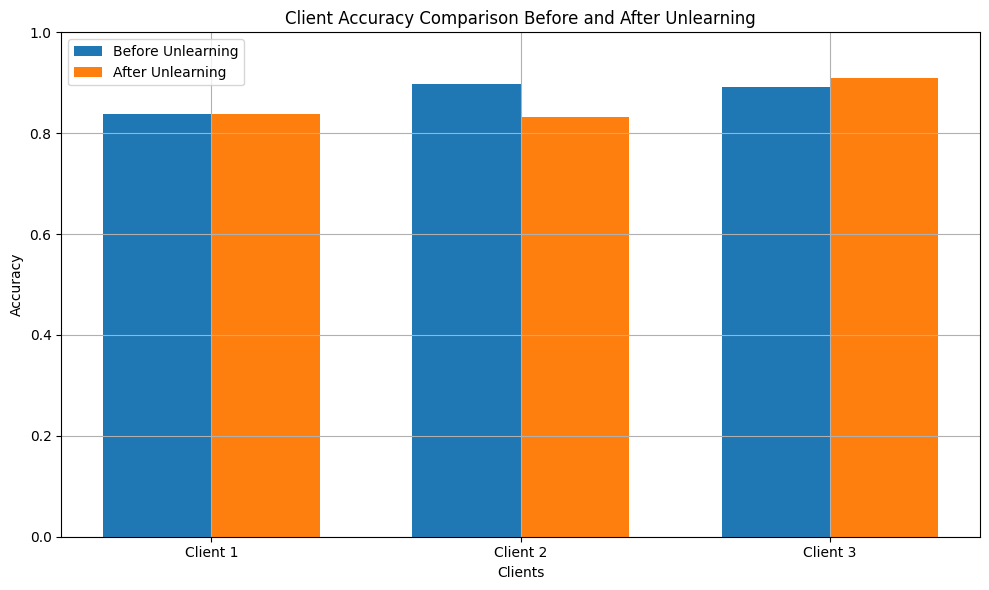

In [ ]:
# -----------------------------
#  Plots: before/after comparison
# -----------------------------
# Client accuracy comparison
x_labels = [f"Client {i+1}" for i in range(num_clients)]
x = np.arange(len(x_labels))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, client_acc_before_unlearning, width, label='Before Unlearning')
plt.bar(x + width/2, client_acc_after_unlearning, width, label='After Unlearning')
plt.xlabel("Clients")
plt.ylabel("Accuracy")
plt.title("Client Accuracy Comparison Before and After Unlearning")
plt.xticks(x, x_labels)
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

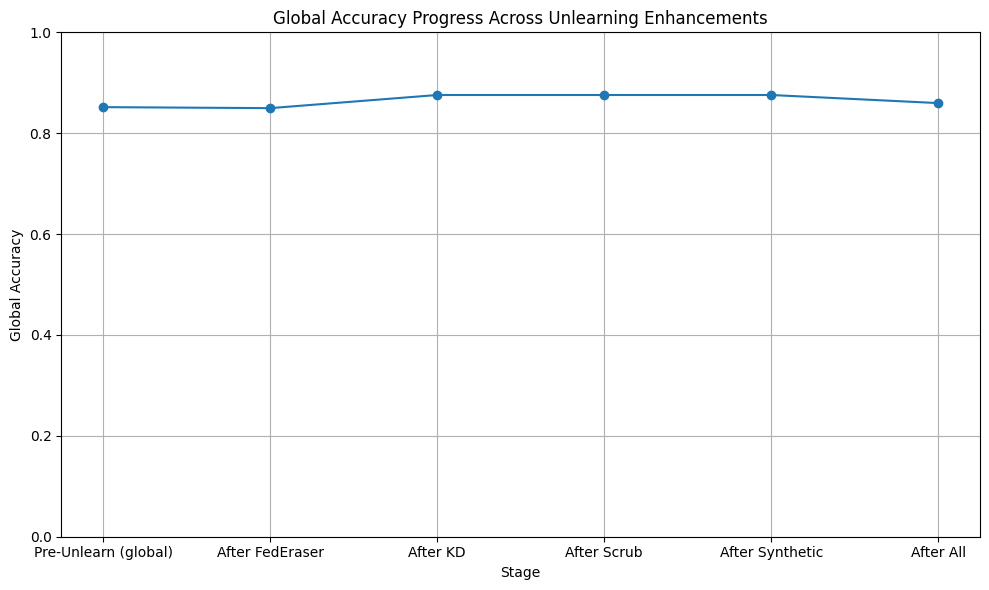


--- Summary ---
Global accuracy BEFORE unlearning: 0.8517
Global accuracy AFTER all enhancements:  0.8597
MIA confidences (teacher / after): 0.8567 / 0.8620
Done.


In [ ]:
# Global accuracy across major stages
stages = ['Pre-Unlearn (global)', 'After FedEraser', 'After KD', 'After Scrub', 'After Synthetic', 'After All']
values = [global_acc_before_unlearning, global_acc_after_federaser, global_acc_after_kd, global_acc_after_scrub, global_acc_after_synthetic, global_acc_after_all]

plt.figure(figsize=(10, 6))
plt.plot(stages, values, marker='o')
plt.xlabel("Stage")
plt.ylabel("Global Accuracy")
plt.title("Global Accuracy Progress Across Unlearning Enhancements")
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n--- Summary ---")
print(f"Global accuracy BEFORE unlearning: {global_acc_before_unlearning:.4f}")
print(f"Global accuracy AFTER all enhancements:  {global_acc_after_all:.4f}")
print("MIA confidences (teacher / after):", f"{forgotten_conf_teacher:.4f}", "/", f"{forgotten_conf_after:.4f}")
print("Done.")